# Optimisation des niveaux de stock avec l’EOQ — InnoMoov

## Contexte

InnoMoov développe des solutions de mobilité intelligente, notamment pour la gestion de flottes électriques et la supervision des batteries de véhicules électriques.

Dans cette étude, nous nous intéressons au produit **IM-BatteryTrack**, un module de supervision intelligente des batteries de véhicules électriques.

L’objectif est d’optimiser les niveaux de stock des composants nécessaires à sa fabrication, à partir de l’évolution réelle du marché des véhicules électriques.

## Objectifs de l’étude

Pour répondre aux quatre étapes demandées :

1. Exploiter des données mensuelles de ventes ou d’immatriculations de véhicules électriques sur deux années historiques :

   * année **n-1 : 2024** ;
   * année **n : 2025**.

2. Construire des prévisions mensuelles de ventes pour l’année **n+1 : 2026**, en tenant compte :

   * de la tendance observée ;
   * de la saisonnalité mensuelle ;
   * du contexte du marché de la mobilité électrique.

3. Calculer la **quantité économique de commande** ou **EOQ** pour chaque mois de 2026.

4. Comparer les quantités EOQ obtenues avec une seconde méthode de commande moins fiable, fondée sur une estimation simplifiée ou un scénario arbitraire.

## Problématique industrielle

Comment InnoMoov peut-elle anticiper ses besoins en composants pour IM-BatteryTrack, tout en réduisant les coûts de commande et de stockage ?

L’objectif final est de passer d’une gestion de stock réactive à une gestion prévisionnelle, intégrée à la logique ERP, Supply Chain et Industrie 4.0.


---

## Source des données historiques

Les données utilisées dans cette étude correspondent aux immatriculations mensuelles de voitures particulières neuves électriques en France.

Elles proviennent du Service des données et études statistiques (SDES), organisme rattaché au ministère chargé de la Transition écologique.

Les données couvrent deux années historiques :

- **2024** : année n-1 ;
- **2025** : année n.

La variable étudiée est le nombre mensuel d’immatriculations de véhicules électriques. Elle représente un indicateur de demande du marché pour le produit **IM-BatteryTrack**, destiné à la supervision intelligente des batteries de véhicules électriques.

Ces données seront utilisées pour :

1. analyser l’évolution mensuelle de la demande ;
2. identifier une éventuelle saisonnalité ;
3. construire une prévision pour l’année 2026 ;
4. calculer les quantités économiques de commande mensuelles.

---

In [1]:
%pip install -q openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

file_path = "sdes_immatriculations_12_2025.xlsx"

# Lecture 
raw_data = pd.read_excel(file_path, sheet_name=0, header=None)

# Aperçu des premières lignes du fichier brut
display(raw_data.head(8))

# Informations générales sur le fichier
print("Dimensions du fichier :", raw_data.shape)
print("Nom de la feuille analysée : 2025_12")

,0,1,2,3,4,5,6,7,8,9,10
0,Immatriculations mensuelles de voitures neuves...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Gazole (thermique),Essence (thermique),hybride gazole non rechargeable,hybride essence non rechargeable,gazole\n(y compris hybrides non rechargeables),essence\n(y compris hybrides non rechargeables),hybride rechargeable,Electrique,Gaz & ND,Total
3,2011_01,133299,50320,12,896,133311,51216,3,100,4320,188950
4,2011_02,144175,60340,25,993,144200,61333,2,138,1776,207449
5,2011_03,176451,78082,84,1322,176535,79404,1,250,4400,260590
6,2011_04,125996,43699,12,1241,126008,44940,5,187,125,171265
7,2011_05,147561,48360,45,991,147606,49351,1,144,231,197333


Dimensions du fichier : (185, 11)
Nom de la feuille analysée : 2025_12


In [3]:
# Reconstruction du tableau avec les en-têtes présents à la ligne 2
historical_data = raw_data.iloc[3:].copy()
historical_data.columns = raw_data.iloc[2].tolist()

# Renommage des colonnes nécessaires à l'étude
historical_data = historical_data.rename(columns={
    historical_data.columns[0]: "Période",
    "Electrique": "Immatriculations_Electriques"
})

# Nettoyage : conservation uniquement des périodes au format YYYY_MM
historical_data["Période"] = historical_data["Période"].astype("string").str.strip()

historical_data = historical_data[
    historical_data["Période"].str.fullmatch(r"\d{4}_\d{2}", na=False)
].copy()

# Extraction de l'année et du mois
historical_data["Année"] = (
    historical_data["Période"].str.split("_").str[0].astype(int)
)

historical_data["Mois"] = (
    historical_data["Période"].str.split("_").str[1].astype(int)
)

# Conversion des immatriculations électriques en données numériques
historical_data["Immatriculations_Electriques"] = pd.to_numeric(
    historical_data["Immatriculations_Electriques"],
    errors="coerce"
)

# Sélection des années historiques : n-1 = 2024 et n = 2025
ev_history = (
    historical_data.loc[
        historical_data["Année"].isin([2024, 2025]),
        ["Période", "Année", "Mois", "Immatriculations_Electriques"]
    ]
    .sort_values(["Année", "Mois"])
    .reset_index(drop=True)
)

display(ev_history)

print("Nombre de mois sélectionnés :", len(ev_history))
print(
    "Période couverte :",
    ev_history["Période"].iloc[0],
    "à",
    ev_history["Période"].iloc[-1]
)

,Période,Année,Mois,Immatriculations_Electriques
0,2024_01,2024,1,20431
1,2024_02,2024,2,26191
2,2024_03,2024,3,34792
3,2024_04,2024,4,25275
4,2024_05,2024,5,24349
5,2024_06,2024,6,30348
6,2024_07,2024,7,17466
7,2024_08,2024,8,13388
8,2024_09,2024,9,28579
9,2024_10,2024,10,21216


Nombre de mois sélectionnés : 24
Période couverte : 2024_01 à 2025_12


---

,Année,Immatriculations_totales,Moyenne_mensuelle,Évolution_annuelle_%
0,2024,295584,24632.0,NaN
1,2025,331200,27600.0,12.05


Année,Mois,Ventes_2024,Ventes_2025,Évolution_2025_vs_2024_%
0,1,20431,20157,-1.34
1,2,26191,25682,-1.94
2,3,34792,29587,-14.96
3,4,25275,25882,2.40
4,5,24349,19666,-19.23
5,6,30348,29574,-2.55
6,7,17466,19955,14.25
7,8,13388,17343,29.54
8,9,28579,31752,11.10
9,10,21216,34506,62.64


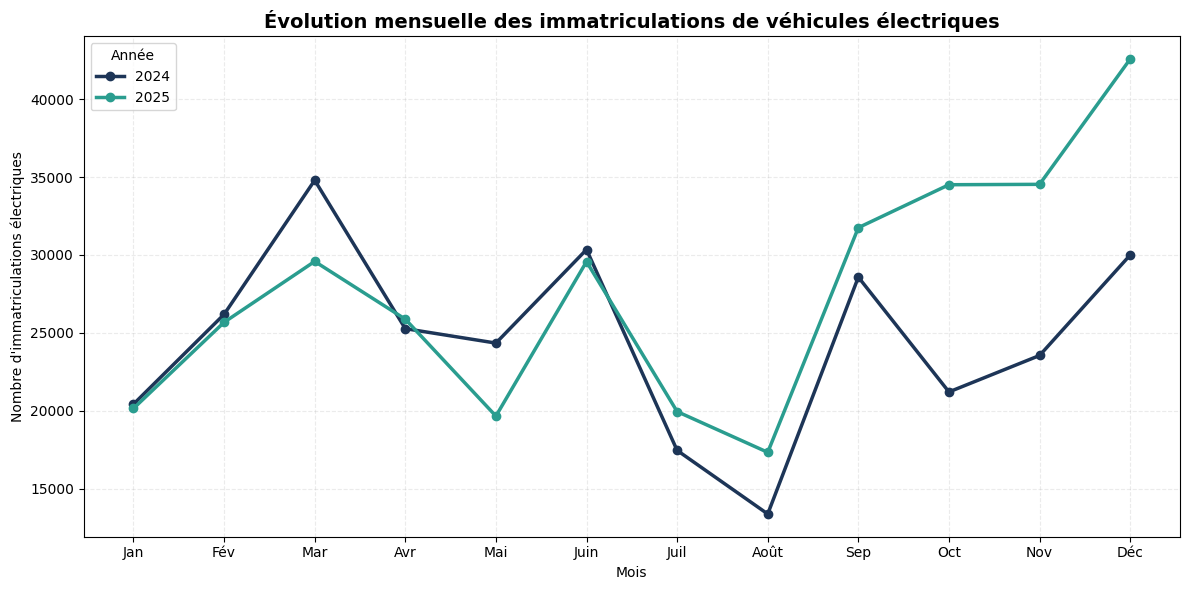

In [4]:
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Synthèse annuelle des immatriculations électriques
# -------------------------------------------------------------------

annual_summary = (
    ev_history.groupby("Année", as_index=False)
    .agg(
        Immatriculations_totales=(
            "Immatriculations_Electriques",
            "sum"
        ),
        Moyenne_mensuelle=(
            "Immatriculations_Electriques",
            "mean"
        )
    )
)

annual_summary["Évolution_annuelle_%"] = (
    annual_summary["Immatriculations_totales"]
    .pct_change()
    .mul(100)
    .round(2)
)

display(annual_summary)

# -------------------------------------------------------------------
# Comparaison mensuelle entre 2024 et 2025
# -------------------------------------------------------------------

monthly_comparison = (
    ev_history.pivot(
        index="Mois",
        columns="Année",
        values="Immatriculations_Electriques"
    )
    .rename(
        columns={
            2024: "Ventes_2024",
            2025: "Ventes_2025"
        }
    )
    .reset_index()
)

monthly_comparison["Évolution_2025_vs_2024_%"] = (
    (
        monthly_comparison["Ventes_2025"]
        - monthly_comparison["Ventes_2024"]
    )
    / monthly_comparison["Ventes_2024"]
    * 100
).round(2)

display(monthly_comparison)

# -------------------------------------------------------------------
# Visualisation de l'évolution mensuelle du marché électrique
# -------------------------------------------------------------------

month_labels = [
    "Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
    "Juil", "Août", "Sep", "Oct", "Nov", "Déc"
]

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_comparison["Mois"],
    monthly_comparison["Ventes_2024"],
    marker="o",
    linewidth=2.5,
    color="#1D3557",
    label="2024"
)

plt.plot(
    monthly_comparison["Mois"],
    monthly_comparison["Ventes_2025"],
    marker="o",
    linewidth=2.5,
    color="#2A9D8F",
    label="2025"
)

plt.title(
    "Évolution mensuelle des immatriculations de véhicules électriques",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Mois")
plt.ylabel("Nombre d'immatriculations électriques")
plt.xticks(
    ticks=monthly_comparison["Mois"],
    labels=month_labels
)

plt.grid(alpha=0.25, linestyle="--")
plt.legend(title="Année")
plt.tight_layout()
plt.show()

Les données historiques montrent une croissance du marché français des véhicules électriques entre 2024 et 2025.

| Année | Immatriculations électriques | Moyenne mensuelle | Évolution annuelle |
| ----- | ---------------------------: | ----------------: | -----------------: |
| 2024  |                      295 584 |            24 632 |                  — |
| 2025  |                      331 200 |            27 600 |           +12,05 % |

Le volume annuel d’immatriculations électriques progresse de **12,05 %** entre 2024 et 2025. Cette évolution confirme une dynamique positive du marché de la mobilité électrique.

L’analyse mensuelle révèle également une saisonnalité. Les premiers mois de 2025 restent proches ou légèrement inférieurs aux niveaux observés en 2024, tandis qu’une accélération nette apparaît à partir de l’été. Les mois de septembre à décembre enregistrent les niveaux les plus élevés, avec un pic en décembre.

Pour InnoMoov, les immatriculations de véhicules électriques constituent un indicateur de demande marché pour **IM-BatteryTrack**, le module de supervision intelligente des batteries. Une hausse du parc de véhicules électriques peut entraîner un besoin accru en solutions de suivi, de maintenance et d’optimisation des batteries.

Ces observations serviront de base pour construire les prévisions mensuelles de l’année 2026, en combinant la tendance annuelle de croissance et le profil saisonnier observé.


---

## Prévision des ventes marché pour 2026

Pour construire les prévisions mensuelles de l’année 2026, nous retenons une méthode simple, transparente et adaptée aux données disponibles.

La prévision repose sur deux éléments :

1. **La tendance annuelle du marché**  
   Entre 2024 et 2025, les immatriculations de véhicules électriques ont progressé de **12,05 %**.

2. **La saisonnalité mensuelle observée en 2025**  
   Les volumes mensuels de 2025 servent de référence afin de conserver les variations du marché selon les périodes de l’année : ralentissement estival, reprise à partir de septembre et pic de fin d’année.

La prévision mensuelle 2026 est donc calculée selon la formule suivante :

\[
\text{Prévision 2026}_{m} =
\text{Immatriculations 2025}_{m}
\times (1 + \text{taux de croissance annuel})
\]

avec :

\[
\text{taux de croissance annuel} = 12{,}05\%
\]

Cette méthode constitue une prévision de référence fondée sur la croissance récente du marché.  
Elle ne représente pas les ventes directes d’InnoMoov, mais un indicateur de demande marché pour les modules **IM-BatteryTrack**.

Année,Période,Mois,Ventes_2025,Taux_de_croissance_%,Prévision_Immatriculations_2026
0,2026_01,1,20157,12.05,22586
1,2026_02,2,25682,12.05,28777
2,2026_03,3,29587,12.05,33152
3,2026_04,4,25882,12.05,29001
4,2026_05,5,19666,12.05,22036
5,2026_06,6,29574,12.05,33138
6,2026_07,7,19955,12.05,22360
7,2026_08,8,17343,12.05,19433
8,2026_09,9,31752,12.05,35578
9,2026_10,10,34506,12.05,38664


Prévision annuelle 2026 : 371 111 immatriculations électriques


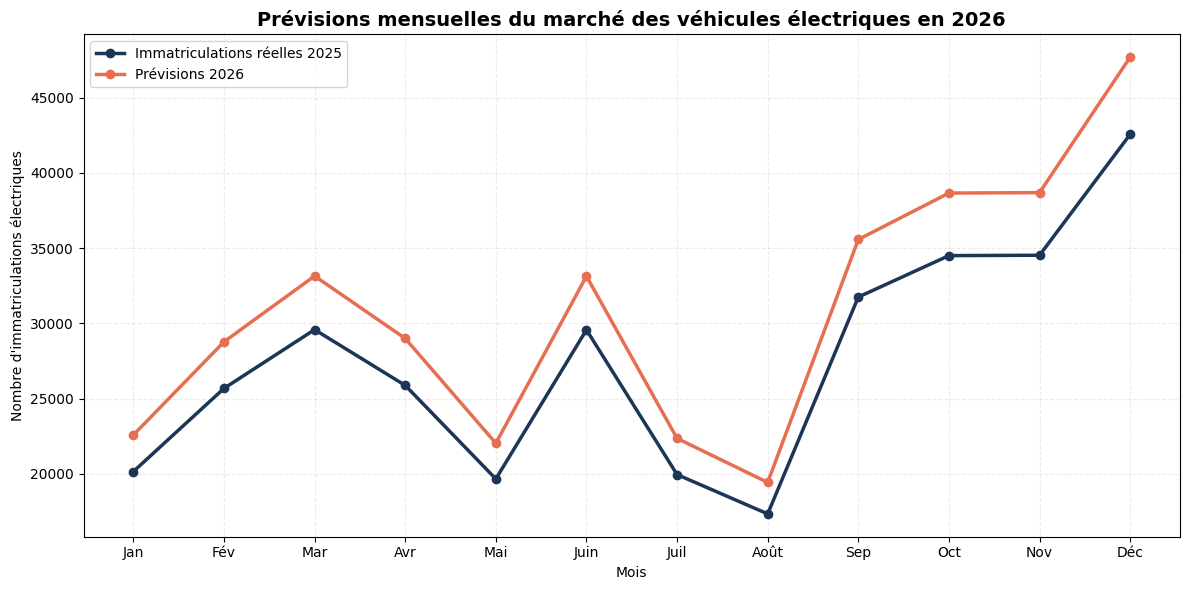

In [5]:
# -------------------------------------------------------------------
# Prévisions mensuelles 2026 à partir de la tendance 2024 → 2025
# -------------------------------------------------------------------

# Taux de croissance observé entre 2024 et 2025
market_growth_rate = (
    annual_summary.loc[
        annual_summary["Année"] == 2025,
        "Évolution_annuelle_%"
    ].iloc[0] / 100
)

# Construction des prévisions à partir des volumes mensuels 2025
forecast_2026 = monthly_comparison[
    ["Mois", "Ventes_2025"]
].copy()

forecast_2026["Taux_de_croissance_%"] = round(
    market_growth_rate * 100,
    2
)

forecast_2026["Prévision_Immatriculations_2026"] = (
    forecast_2026["Ventes_2025"] * (1 + market_growth_rate)
).round().astype(int)

forecast_2026["Période"] = (
    "2026_"
    + forecast_2026["Mois"].astype(str).str.zfill(2)
)

forecast_2026 = forecast_2026[
    [
        "Période",
        "Mois",
        "Ventes_2025",
        "Taux_de_croissance_%",
        "Prévision_Immatriculations_2026"
    ]
]

display(forecast_2026)

print(
    "Prévision annuelle 2026 :",
    f"{forecast_2026['Prévision_Immatriculations_2026'].sum():,}".replace(",", " "),
    "immatriculations électriques"
)

# -------------------------------------------------------------------
# Visualisation : marché réel 2025 vs prévision 2026
# -------------------------------------------------------------------

month_labels = [
    "Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
    "Juil", "Août", "Sep", "Oct", "Nov", "Déc"
]

plt.figure(figsize=(12, 6))

plt.plot(
    forecast_2026["Mois"],
    forecast_2026["Ventes_2025"],
    marker="o",
    linewidth=2.5,
    color="#1D3557",
    label="Immatriculations réelles 2025"
)

plt.plot(
    forecast_2026["Mois"],
    forecast_2026["Prévision_Immatriculations_2026"],
    marker="o",
    linewidth=2.5,
    color="#E76F51",
    label="Prévisions 2026"
)

plt.title(
    "Prévisions mensuelles du marché des véhicules électriques en 2026",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Mois")
plt.ylabel("Nombre d'immatriculations électriques")

plt.xticks(
    ticks=forecast_2026["Mois"],
    labels=month_labels
)

plt.grid(alpha=0.25, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

Les prévisions indiquent une poursuite de la croissance du marché des véhicules électriques en 2026.

En appliquant le taux de croissance annuel observé entre 2024 et 2025, soit **+12,05 %**, le marché atteindrait environ **371 110 immatriculations électriques** en 2026.

La courbe prévisionnelle conserve la même saisonnalité que celle observée en 2025 :

* un niveau plus modéré au début de l’année ;
* un ralentissement durant l’été, notamment en juillet et août ;
* une forte reprise à partir de septembre ;
* un pic de demande attendu en fin d’année, particulièrement en décembre.

Cette tendance est logique, car le modèle utilisé applique un même taux de croissance à chaque mois de 2025. La courbe 2026 présente donc une forme très proche de celle de 2025, mais avec des volumes supérieurs.

Cette première prévision constitue un scénario de référence simple et transparent. Elle permet à InnoMoov d’anticiper une hausse des besoins liés aux véhicules électriques, notamment pour le produit **IM-BatteryTrack**, dédié à la supervision intelligente des batteries.

Cependant, cette méthode reste volontairement simplifiée. Elle ne prend pas encore en compte des facteurs externes tels que :

* l’évolution des aides à l’achat ;
* les changements réglementaires ;
* la concurrence ;
* les tensions d’approvisionnement ;
* les évolutions du prix de l’énergie ;
* ou les variations spécifiques du marché automobile.

Dans la suite de l’étude, cette prévision marché sera convertie en besoin estimé de composants pour InnoMoov afin de calculer les quantités économiques de commande mensuelles avec la méthode EOQ.


---

## Conversion de la prévision marché en demande InnoMoov

Les immatriculations nationales de véhicules électriques constituent un indicateur de marché. Elles doivent être converties en une demande estimée pour le produit **IM-BatteryTrack**.

Pour cette étude, les hypothèses suivantes sont retenues :

* InnoMoov cible des clients B2B : opérateurs de flottes, collectivités et entreprises ;
* chaque unité **IM-BatteryTrack** est associée à un véhicule électrique ou à une batterie supervisée ;
* InnoMoov vise une part prudente de **0,30 %** du marché mensuel des nouvelles immatriculations électriques ;
* la demande estimée correspond donc au nombre prévisionnel de modules IM-BatteryTrack à vendre et à produire chaque mois.

La formule appliquée est la suivante :

$$
\mathrm{Demande\ InnoMoov}_{m}
=
\mathrm{Prévision\ marché\ 2026}_{m}
\times 0{,}003
$$

Cette hypothèse permet de construire un scénario réaliste pour une entreprise B2B de taille intermédiaire, tout en restant prudente par rapport à la taille globale du marché français.

Les besoins estimés en IM-BatteryTrack serviront ensuite de base au calcul des quantités économiques de commande mensuelles, afin d’optimiser le stock des composants nécessaires à la fabrication.


In [6]:
# -------------------------------------------------------------------
# Conversion des prévisions de marché 2026 en demande InnoMoov
# Hypothèse : InnoMoov capte 0,30 % du marché mensuel des VE neufs
# -------------------------------------------------------------------

market_share_innomoov = 0.003  # 0,30 %

innomoov_demand_2026 = forecast_2026[
    [
        "Période",
        "Mois",
        "Prévision_Immatriculations_2026"
    ]
].copy()

innomoov_demand_2026["Part_de_marché_InnoMoov_%"] = (
    market_share_innomoov * 100
)

innomoov_demand_2026["Demande_estimée_IM_BatteryTrack"] = (
    innomoov_demand_2026["Prévision_Immatriculations_2026"]
    * market_share_innomoov
).round().astype(int)

display(innomoov_demand_2026)

print(
    "Demande annuelle estimée pour IM-BatteryTrack :",
    f"{innomoov_demand_2026['Demande_estimée_IM_BatteryTrack'].sum():,}".replace(",", " "),
    "unités"
)

print(
    "Demande mensuelle minimale :",
    innomoov_demand_2026["Demande_estimée_IM_BatteryTrack"].min(),
    "unités"
)

print(
    "Demande mensuelle maximale :",
    innomoov_demand_2026["Demande_estimée_IM_BatteryTrack"].max(),
    "unités"
)

Année,Période,Mois,Prévision_Immatriculations_2026,Part_de_marché_InnoMoov_%,Demande_estimée_IM_BatteryTrack
0,2026_01,1,22586,0.3,68
1,2026_02,2,28777,0.3,86
2,2026_03,3,33152,0.3,99
3,2026_04,4,29001,0.3,87
4,2026_05,5,22036,0.3,66
5,2026_06,6,33138,0.3,99
6,2026_07,7,22360,0.3,67
7,2026_08,8,19433,0.3,58
8,2026_09,9,35578,0.3,107
9,2026_10,10,38664,0.3,116


Demande annuelle estimée pour IM-BatteryTrack : 1 112 unités
Demande mensuelle minimale : 58 unités
Demande mensuelle maximale : 143 unités


### Interprétation de la demande estimée pour IM-BatteryTrack

À partir des prévisions du marché français des véhicules électriques et d’une hypothèse prudente de pénétration de **0,30 %**, InnoMoov pourrait viser une demande annuelle estimée à **1 112 modules IM-BatteryTrack** en 2026.

La demande mensuelle varie entre **58 unités** et **143 unités**. Cette variation traduit la saisonnalité observée sur le marché des véhicules électriques :

* les besoins sont plus faibles durant la période estivale ;
* ils progressent fortement à partir de septembre ;
* le niveau de demande le plus élevé est attendu en fin d’année.

Pour InnoMoov, cette estimation permet de passer d’un indicateur marché global à un besoin opérationnel exploitable pour l’ERP, les achats et la gestion des stocks.

Il est important de préciser que la part de marché de **0,30 %** est une hypothèse de travail. Elle ne représente pas une donnée réelle de vente InnoMoov, mais permet de construire un scénario cohérent et prudent pour calculer les besoins d’approvisionnement.

Cette demande estimée servira désormais de base au calcul de l’EOQ mensuel des composants nécessaires à la fabrication d’IM-BatteryTrack.


---

## Composant étudié pour l’EOQ

L’EOQ sera calculé pour la **carte électronique de supervision batterie** utilisée dans le produit **IM-BatteryTrack**.

Cette carte constitue un composant stratégique, car elle assure la collecte, le traitement et la remontée des données liées à l’état des batteries de véhicules électriques.

Dans cette étude, nous retenons l’hypothèse suivante :

$$
1\ \mathrm{IM\text{-}BatteryTrack}
=
1\ \mathrm{carte\ électronique\ de\ supervision\ batterie}
$$

La demande mensuelle estimée pour IM-BatteryTrack correspond donc directement au besoin mensuel de cartes électroniques à approvisionner.

L’objectif est de déterminer, pour chaque mois de 2026, la quantité économique de commande permettant de limiter simultanément :

* les coûts de passation de commande ;
* les coûts de stockage ;
* le risque de surstock ou de rupture sur un composant essentiel à la production.


## Hypothèses économiques pour le calcul de l’EOQ

Pour déterminer la quantité économique de commande des cartes électroniques de supervision batterie, deux paramètres de coût sont retenus.

| Paramètre | Valeur retenue | Interprétation |
|---|---:|---|
| Coût de passation d’une commande | 350 € | Traitement de la commande fournisseur, réception, contrôle administratif et mise en stock |
| Coût de stockage | 25 € par carte et par mois | Immobilisation financière, espace de stockage, manutention et risque d’obsolescence |

La quantité économique de commande est calculée à partir de la formule suivante :

**EOQ = racine carrée de ((2 × Demande × Coût de commande) / Coût de stockage)**

L’objectif est d’identifier la quantité de cartes à commander qui équilibre les coûts de commande et les coûts de stockage.


In [12]:
import numpy as np

# -------------------------------------------------------------------
# Paramètres économiques retenus pour les cartes de supervision batterie
# Les coûts sont exprimés sur une base mensuelle, car l'EOQ est calculé
# à partir de la demande mensuelle prévue pour 2026.
# -------------------------------------------------------------------

ordering_cost = 350          # € par commande fournisseur
holding_cost_monthly = 25    # € par carte stockée et par mois

# Création de la table de calcul EOQ à partir de la demande estimée
eoq_2026 = innomoov_demand_2026[
    [
        "Période",
        "Mois",
        "Demande_estimée_IM_BatteryTrack"
    ]
].copy()

# Une carte électronique est nécessaire pour fabriquer un IM-BatteryTrack
eoq_2026["Demande_cartes_supervision"] = (
    eoq_2026["Demande_estimée_IM_BatteryTrack"]
)

# Formule EOQ :
# EOQ = sqrt((2 × demande × coût de commande) / coût de stockage)
eoq_2026["EOQ_théorique"] = np.sqrt(
    (
        2
        * eoq_2026["Demande_cartes_supervision"]
        * ordering_cost
    )
    / holding_cost_monthly
)

# Quantité entière à commander
eoq_2026["EOQ_arrondie"] = (
    eoq_2026["EOQ_théorique"]
    .round()
    .astype(int)
)

# Nombre indicatif de commandes nécessaires dans le mois
eoq_2026["Nombre_commandes_estimé"] = (
    eoq_2026["Demande_cartes_supervision"]
    / eoq_2026["EOQ_arrondie"]
).round(2)

display(eoq_2026)

print(
    "EOQ mensuelle minimale :",
    eoq_2026["EOQ_arrondie"].min(),
    "cartes"
)

print(
    "EOQ mensuelle maximale :",
    eoq_2026["EOQ_arrondie"].max(),
    "cartes"
)

print(
    "EOQ mensuelle moyenne :",
    round(eoq_2026["EOQ_arrondie"].mean(), 1),
    "cartes"
)

Année,Période,Mois,Demande_estimée_IM_BatteryTrack,Demande_cartes_supervision,EOQ_théorique,EOQ_arrondie,Nombre_commandes_estimé
0,2026_01,1,68,68,43.634848,44,1.55
1,2026_02,2,86,86,49.071377,49,1.76
2,2026_03,3,99,99,52.649786,53,1.87
3,2026_04,4,87,87,49.355851,49,1.78
4,2026_05,5,66,66,42.988371,43,1.53
5,2026_06,6,99,99,52.649786,53,1.87
6,2026_07,7,67,67,43.312816,43,1.56
7,2026_08,8,58,58,40.298883,40,1.45
8,2026_09,9,107,107,54.735729,55,1.95
9,2026_10,10,116,116,56.991227,57,2.04


EOQ mensuelle minimale : 40 cartes
EOQ mensuelle maximale : 63 cartes
EOQ mensuelle moyenne : 50.5 cartes


Avec un coût de commande de **350 €** et un coût de stockage de **25 € par carte et par mois**, les quantités économiques de commande obtenues sont :

| Indicateur | Résultat |
|---|---:|
| EOQ mensuelle minimale | 40 cartes |
| EOQ mensuelle maximale | 63 cartes |
| EOQ mensuelle moyenne | 50,5 cartes |

Ces résultats montrent que l’EOQ est inférieure à la demande mensuelle sur plusieurs mois. Ce n’est pas une erreur : l’EOQ représente la quantité optimale par commande, et non la demande totale du mois.

Comme le coût de stockage est élevé, le modèle recommande de commander des lots plus petits afin de limiter l’immobilisation financière et le risque d’obsolescence des cartes électroniques.

En contrepartie, InnoMoov devra passer environ **1,45 à 2,27 commandes par mois** selon les périodes.

---

## Comparaison avec une estimation moins fiable

Pour évaluer l’intérêt de la méthode EOQ, nous allons comparer les quantités optimales obtenues avec un second scénario de prévision plus simple.

### Scénario de référence

Le scénario de référence utilise :

* les données réelles d’immatriculations 2024 et 2025 ;
* la croissance annuelle observée de **12,05 %** ;
* la saisonnalité mensuelle observée en 2025.

Il fournit une estimation de demande 2026 plus complète pour le produit IM-BatteryTrack.

### Scénario naïf

Le scénario alternatif suppose que les volumes mensuels de 2026 seront identiques à ceux de 2025.

Cette estimation est moins fiable, car elle :

* ne prend pas en compte la croissance du marché électrique ;
* sous-estime potentiellement les besoins réels d’InnoMoov ;
* peut conduire à des commandes insuffisantes durant les mois de forte demande.

Pour chaque mois, nous calculerons donc :

* l’EOQ basée sur la prévision de référence ;
* l’EOQ basée sur le scénario naïf ;
* l’écart entre les deux méthodes.

Cette comparaison permettra de mesurer l’impact d’une prévision de demande moins robuste sur les décisions d’approvisionnement.


Année,Période,Mois,Demande_référence_2026,EOQ_référence,Demande_naïve_2026,EOQ_naïve,Écart_demande,Écart_EOQ,Écart_EOQ_%
0,2026_01,1,68,44,60,41,8,3,7.32
1,2026_02,2,86,49,77,46,9,3,6.52
2,2026_03,3,99,53,89,50,10,3,6.00
3,2026_04,4,87,49,78,47,9,2,4.26
4,2026_05,5,66,43,59,41,7,2,4.88
5,2026_06,6,99,53,89,50,10,3,6.00
6,2026_07,7,67,43,60,41,7,2,4.88
7,2026_08,8,58,40,52,38,6,2,5.26
8,2026_09,9,107,55,95,52,12,3,5.77
9,2026_10,10,116,57,104,54,12,3,5.56


Demande annuelle scénario de référence : 1112 cartes
Demande annuelle scénario naïf : 995 cartes
Écart annuel de demande : 117 cartes
Écart moyen entre les EOQ : 2.7 cartes par mois


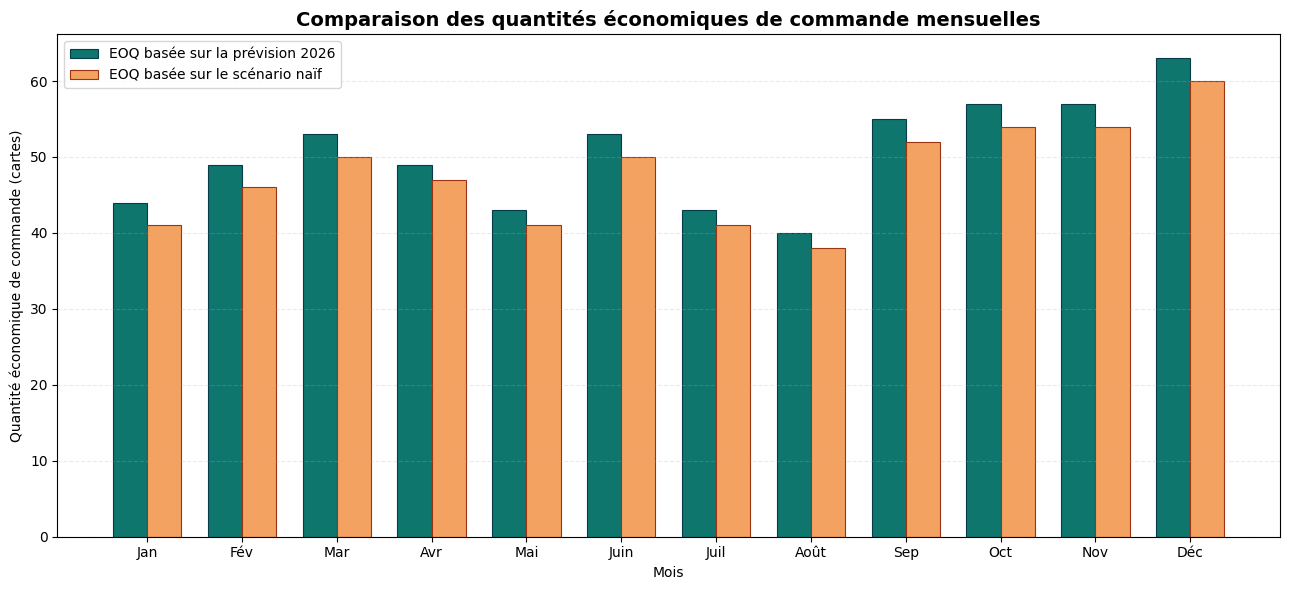

In [8]:
# -------------------------------------------------------------------
# Comparaison : prévision de référence vs scénario naïf
# Référence : croissance du marché prise en compte (+12,05 %)
# Naïf      : volumes 2026 supposés identiques à ceux de 2025
# -------------------------------------------------------------------

comparison_eoq = eoq_2026[
    [
        "Période",
        "Mois",
        "Demande_cartes_supervision",
        "EOQ_arrondie"
    ]
].copy()

comparison_eoq = comparison_eoq.rename(columns={
    "Demande_cartes_supervision": "Demande_référence_2026",
    "EOQ_arrondie": "EOQ_référence"
})

# Demande naïve : aucune croissance appliquée au niveau de 2025
comparison_eoq["Demande_naïve_2026"] = (
    forecast_2026["Ventes_2025"] * market_share_innomoov
).round().astype(int)

# EOQ associée au scénario naïf
comparison_eoq["EOQ_naïve"] = np.sqrt(
    (
        2
        * comparison_eoq["Demande_naïve_2026"]
        * ordering_cost
    )
    / holding_cost_monthly
).round().astype(int)

# Écarts entre les deux approches
comparison_eoq["Écart_demande"] = (
    comparison_eoq["Demande_référence_2026"]
    - comparison_eoq["Demande_naïve_2026"]
)

comparison_eoq["Écart_EOQ"] = (
    comparison_eoq["EOQ_référence"]
    - comparison_eoq["EOQ_naïve"]
)

comparison_eoq["Écart_EOQ_%"] = (
    comparison_eoq["Écart_EOQ"]
    / comparison_eoq["EOQ_naïve"]
    * 100
).round(2)

display(comparison_eoq)

print(
    "Demande annuelle scénario de référence :",
    comparison_eoq["Demande_référence_2026"].sum(),
    "cartes"
)

print(
    "Demande annuelle scénario naïf :",
    comparison_eoq["Demande_naïve_2026"].sum(),
    "cartes"
)

print(
    "Écart annuel de demande :",
    comparison_eoq["Écart_demande"].sum(),
    "cartes"
)

print(
    "Écart moyen entre les EOQ :",
    round(comparison_eoq["Écart_EOQ"].mean(), 1),
    "cartes par mois"
)

# -------------------------------------------------------------------
# Graphique comparatif des EOQ mensuelles
# -------------------------------------------------------------------

month_labels = [
    "Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
    "Juil", "Août", "Sep", "Oct", "Nov", "Déc"
]

x = np.arange(len(comparison_eoq))
bar_width = 0.36

plt.figure(figsize=(13, 6))

plt.bar(
    x - bar_width / 2,
    comparison_eoq["EOQ_référence"],
    width=bar_width,
    color="#0F766E",
    edgecolor="#073B4C",
    linewidth=0.8,
    label="EOQ basée sur la prévision 2026"
)

plt.bar(
    x + bar_width / 2,
    comparison_eoq["EOQ_naïve"],
    width=bar_width,
    color="#F4A261",
    edgecolor="#9A3412",
    linewidth=0.8,
    label="EOQ basée sur le scénario naïf"
)

plt.title(
    "Comparaison des quantités économiques de commande mensuelles",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Mois")
plt.ylabel("Quantité économique de commande (cartes)")
plt.xticks(x, month_labels)
plt.grid(axis="y", alpha=0.25, linestyle="--")
plt.legend()

plt.tight_layout()
plt.show()

La comparaison met en évidence l’impact direct de la qualité des prévisions sur les décisions d’approvisionnement.

| Indicateur | Prévision de référence | Scénario naïf | Écart |
|---|---:|---:|---:|
| Demande annuelle estimée | 1 112 cartes | 995 cartes | 117 cartes |
| Écart moyen d’EOQ mensuelle | — | — | 2,7 cartes |

Le scénario de référence tient compte de la croissance de **12,05 %** observée entre 2024 et 2025. Il anticipe donc une demande plus élevée en 2026.

À l’inverse, le scénario naïf suppose que les volumes de 2026 seront identiques à ceux de 2025. Cette méthode est moins fiable, car elle ignore la dynamique récente du marché des véhicules électriques.

L’écart annuel de **117 cartes** représente environ **10,5 %** du besoin estimé par le scénario de référence. Pour InnoMoov, cette sous-estimation pourrait générer des ruptures de stock sur les cartes électroniques de supervision batterie, des retards de fabrication et une baisse de disponibilité du produit IM-BatteryTrack.

L’EOQ est moins sensible que la demande elle-même, car elle évolue selon une racine carrée. Malgré cela, un écart moyen de **2,7 cartes par mois** reste significatif pour un composant électronique stratégique et pour une entreprise de la taille d’InnoMoov.

La prévision de référence constitue donc l’approche à privilégier pour alimenter l’ERP et planifier les achats de composants.


---

## Comparaison des coûts logistiques

Pour comparer les deux méthodes de manière équitable, les coûts sont calculés en supposant que la demande réelle à satisfaire correspond à la prévision de référence.

La formule du coût total mensuel est :

$$
\mathrm{Coût\ total}
=
\left(
\frac{\mathrm{Demande}}{\mathrm{Quantité\ commandée}}
\times
\mathrm{Coût\ de\ commande}
\right)
+
\left(
\frac{\mathrm{Quantité\ commandée}}{2}
\times
\mathrm{Coût\ de\ stockage}
\right)
$$

Deux stratégies sont comparées :

- **Stratégie de référence** : quantité de commande calculée avec l’EOQ issue de la prévision 2026 ;
- **Stratégie naïve** : quantité de commande calculée à partir des volumes 2025, sans prendre en compte la croissance du marché.

La demande retenue pour le calcul des coûts est la demande de référence 2026. Cette méthode permet de mesurer l’impact économique du choix d’une quantité de commande moins adaptée.

Année,Période,Mois,Demande_référence_2026,Demande_naïve_2026,EOQ_référence,EOQ_naïve,Coût_commande_référence_€,Coût_stockage_référence_€,Coût_total_référence_€,Coût_commande_naïf_€,Coût_stockage_naïf_€,Coût_total_naïf_€,Surcoût_scénario_naïf_€,Cartes_non_anticipées
0,2026_01,1,68,60,44,41,540.91,550.0,1090.91,580.49,512.5,1092.99,2.08,8
1,2026_02,2,86,77,49,46,614.29,612.5,1226.79,654.35,575.0,1229.35,2.56,9
2,2026_03,3,99,89,53,50,653.77,662.5,1316.27,693.00,625.0,1318.00,1.73,10
3,2026_04,4,87,78,49,47,621.43,612.5,1233.93,647.87,587.5,1235.37,1.44,9
4,2026_05,5,66,59,43,41,537.21,537.5,1074.71,563.41,512.5,1075.91,1.21,7
5,2026_06,6,99,89,53,50,653.77,662.5,1316.27,693.00,625.0,1318.00,1.73,10
6,2026_07,7,67,60,43,41,545.35,537.5,1082.85,571.95,512.5,1084.45,1.60,7
7,2026_08,8,58,52,40,38,507.50,500.0,1007.50,534.21,475.0,1009.21,1.71,6
8,2026_09,9,107,95,55,52,680.91,687.5,1368.41,720.19,650.0,1370.19,1.78,12
9,2026_10,10,116,104,57,54,712.28,712.5,1424.78,751.85,675.0,1426.85,2.07,12


,Indicateur,Scénario de référence,Scénario naïf
0,Coût total annuel,15149.14,15171.34
1,Coût de commande annuel,7574.14,7996.34
2,Coût de stockage annuel,7575.00,7175.00
3,Cartes non anticipées,0.00,117.00


Surcoût annuel du scénario naïf : 22.20 €
Cartes non anticipées sur l'année : 117


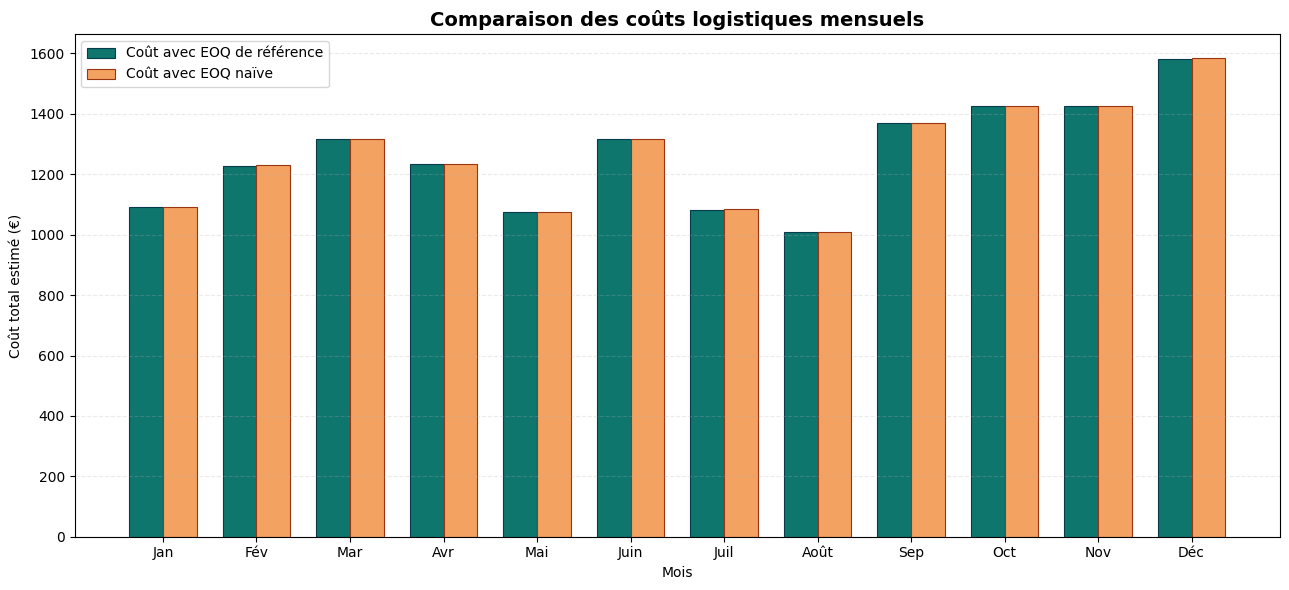

In [13]:
# -------------------------------------------------------------------
# Comparaison des coûts de commande et de stockage
# La demande de référence 2026 est utilisée pour comparer les deux
# stratégies dans les mêmes conditions de besoin réel.
# -------------------------------------------------------------------

cost_comparison = comparison_eoq[
    [
        "Période",
        "Mois",
        "Demande_référence_2026",
        "Demande_naïve_2026",
        "EOQ_référence",
        "EOQ_naïve"
    ]
].copy()

# --- Stratégie de référence : EOQ calculée à partir de la prévision 2026

cost_comparison["Coût_commande_référence_€"] = (
    cost_comparison["Demande_référence_2026"]
    / cost_comparison["EOQ_référence"]
    * ordering_cost
)

cost_comparison["Coût_stockage_référence_€"] = (
    cost_comparison["EOQ_référence"]
    / 2
    * holding_cost_monthly
)

cost_comparison["Coût_total_référence_€"] = (
    cost_comparison["Coût_commande_référence_€"]
    + cost_comparison["Coût_stockage_référence_€"]
)

# --- Stratégie naïve : EOQ calculée à partir de niveaux 2025

cost_comparison["Coût_commande_naïf_€"] = (
    cost_comparison["Demande_référence_2026"]
    / cost_comparison["EOQ_naïve"]
    * ordering_cost
)

cost_comparison["Coût_stockage_naïf_€"] = (
    cost_comparison["EOQ_naïve"]
    / 2
    * holding_cost_monthly
)

cost_comparison["Coût_total_naïf_€"] = (
    cost_comparison["Coût_commande_naïf_€"]
    + cost_comparison["Coût_stockage_naïf_€"]
)

# --- Écart de coût et risque opérationnel lié à la sous-estimation

cost_comparison["Surcoût_scénario_naïf_€"] = (
    cost_comparison["Coût_total_naïf_€"]
    - cost_comparison["Coût_total_référence_€"]
)

cost_comparison["Cartes_non_anticipées"] = (
    cost_comparison["Demande_référence_2026"]
    - cost_comparison["Demande_naïve_2026"]
)

# Arrondis pour une lecture plus claire
cost_comparison = cost_comparison.round(2)

display(cost_comparison)

# -------------------------------------------------------------------
# Synthèse annuelle
# -------------------------------------------------------------------

annual_cost_summary = pd.DataFrame({
    "Indicateur": [
        "Coût total annuel",
        "Coût de commande annuel",
        "Coût de stockage annuel",
        "Cartes non anticipées"
    ],
    "Scénario de référence": [
        cost_comparison["Coût_total_référence_€"].sum(),
        cost_comparison["Coût_commande_référence_€"].sum(),
        cost_comparison["Coût_stockage_référence_€"].sum(),
        0
    ],
    "Scénario naïf": [
        cost_comparison["Coût_total_naïf_€"].sum(),
        cost_comparison["Coût_commande_naïf_€"].sum(),
        cost_comparison["Coût_stockage_naïf_€"].sum(),
        cost_comparison["Cartes_non_anticipées"].sum()
    ]
}).round(2)

display(annual_cost_summary)

print(
    "Surcoût annuel du scénario naïf :",
    f"{cost_comparison['Surcoût_scénario_naïf_€'].sum():.2f} €"
)

print(
    "Cartes non anticipées sur l'année :",
    int(cost_comparison["Cartes_non_anticipées"].sum())
)

# -------------------------------------------------------------------
# Graphique comparatif des coûts totaux mensuels
# -------------------------------------------------------------------

month_labels = [
    "Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
    "Juil", "Août", "Sep", "Oct", "Nov", "Déc"
]

x = np.arange(len(cost_comparison))
bar_width = 0.36

plt.figure(figsize=(13, 6))

bars_reference = plt.bar(
    x - bar_width / 2,
    cost_comparison["Coût_total_référence_€"],
    width=bar_width,
    color="#0F766E",
    edgecolor="#073B4C",
    linewidth=0.8,
    label="Coût avec EOQ de référence"
)

bars_naive = plt.bar(
    x + bar_width / 2,
    cost_comparison["Coût_total_naïf_€"],
    width=bar_width,
    color="#F4A261",
    edgecolor="#9A3412",
    linewidth=0.8,
    label="Coût avec EOQ naïve"
)

plt.title(
    "Comparaison des coûts logistiques mensuels",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Mois")
plt.ylabel("Coût total estimé (€)")
plt.xticks(x, month_labels)
plt.grid(axis="y", alpha=0.25, linestyle="--")
plt.legend()

plt.tight_layout()
plt.show()

### Interprétation finale de la comparaison des coûts

La stratégie basée sur la prévision de référence présente un coût logistique annuel estimé à **15 149,14 €**, contre **15 171,34 €** pour le scénario naïf.

| Indicateur | Scénario de référence | Scénario naïf |
|---|---:|---:|
| Coût total annuel | 15 149,14 € | 15 171,34 € |
| Coût de commande annuel | 7 574,14 € | 7 996,34 € |
| Coût de stockage annuel | 7 575,00 € | 7 175,00 € |
| Cartes non anticipées | 0 | 117 |

Le scénario naïf présente un surcoût direct de **22,20 €**. Cet écart reste limité, car l’EOQ évolue selon une racine carrée de la demande.

Cependant, le vrai problème du scénario naïf est opérationnel : il sous-estime la demande annuelle de **117 cartes électroniques**.

Pour InnoMoov, cela peut entraîner des ruptures de stock, des commandes urgentes, des retards de production ou une indisponibilité du produit **IM-BatteryTrack**.

La prévision de référence reste donc la meilleure stratégie, car elle sécurise davantage les approvisionnements tout en maintenant un coût logistique maîtrisé.

---

# Conclusion générale

Cette étude a permis d’appliquer la méthode de l’**Economic Order Quantity (EOQ)** à un cas industriel cohérent avec l’activité d’InnoMoov.

L’objectif était d’optimiser les niveaux de stock d’un composant stratégique : la **carte électronique de supervision batterie**, utilisée dans la fabrication du module **IM-BatteryTrack**.

L’analyse s’appuie sur les immatriculations mensuelles de véhicules électriques en France sur les années **2024** et **2025**. Ces données ont été utilisées comme indicateur externe de marché afin d’estimer la demande future pour les solutions de supervision batterie proposées par InnoMoov.

Les données historiques montrent une progression du marché électrique :

* **295 584 immatriculations** en 2024 ;
* **331 200 immatriculations** en 2025 ;
* soit une croissance annuelle de **12,05 %**.

À partir de cette tendance, une prévision mensuelle a été construite pour l’année **2026**. Cette prévision a ensuite été convertie en besoin estimé pour InnoMoov, en retenant une hypothèse prudente de part de marché de **0,30 %**.

La demande annuelle estimée pour le produit **IM-BatteryTrack** atteint ainsi :

**1 112 modules en 2026**

Comme un module IM-BatteryTrack nécessite une carte électronique de supervision batterie, cela correspond également à un besoin annuel estimé de **1 112 cartes électroniques**.

Pour le calcul de l’EOQ, les hypothèses économiques retenues sont les suivantes :

| Paramètre        |             Valeur retenue |
| ---------------- | -------------------------: |
| Coût de commande |         350 € par commande |
| Coût de stockage | 25 € par carte et par mois |

Les résultats EOQ obtenus sont :

| Indicateur             |    Résultat |
| ---------------------- | ----------: |
| EOQ mensuelle minimale |   40 cartes |
| EOQ mensuelle maximale |   63 cartes |
| EOQ mensuelle moyenne  | 50,5 cartes |

Ces résultats montrent que l’EOQ est généralement inférieure à la demande mensuelle. Ce n’est pas une anomalie : l’EOQ représente la **quantité optimale à commander par commande**, et non la demande totale du mois.

Dans le cas d’InnoMoov, le coût de stockage étant élevé, le modèle recommande de commander des lots plus petits afin de limiter l’immobilisation financière, les coûts de stockage et le risque d’obsolescence des composants électroniques.

Une comparaison a également été réalisée avec un scénario naïf, dans lequel les besoins 2026 sont supposés identiques aux volumes 2025. Ce scénario ne tient pas compte de la croissance du marché électrique.

Les résultats de comparaison sont les suivants :

| Indicateur               | Scénario de référence |             Scénario naïf |
| ------------------------ | --------------------: | ------------------------: |
| Demande annuelle estimée |          1 112 cartes |                995 cartes |
| Écart de demande         |                     — | 117 cartes non anticipées |
| Coût total annuel        |           15 149,14 € |               15 171,34 € |
| Surcoût du scénario naïf |                     — |                   22,20 € |

Même si le surcoût direct du scénario naïf reste limité, le risque principal est opérationnel. Le scénario naïf sous-estime les besoins annuels de **117 cartes électroniques**, ce qui peut entraîner des ruptures de stock, des commandes urgentes, des retards de production ou une indisponibilité du produit IM-BatteryTrack.

La prévision de référence doit donc être privilégiée. Elle permet à InnoMoov de mieux anticiper la demande, de sécuriser ses approvisionnements, d’alimenter plus efficacement l’ERP et de planifier la production de manière plus fiable.

Cette étude montre que l’EOQ ne sert pas uniquement à réduire les coûts de stockage. Associée à des données historiques et à une prévision de marché, elle devient un véritable outil d’aide à la décision pour une Supply Chain plus prévisible, plus maîtrisée et mieux adaptée aux exigences de l’Industrie 4.0.

## Limites et perspectives

Le modèle proposé reste volontairement simplifié. Dans un contexte industriel réel, il pourrait être enrichi avec :

* un stock de sécurité ;
* des délais fournisseurs variables ;
* des coûts de commande urgente ;
* des risques de rupture ;
* des contraintes de capacité de stockage ;
* plusieurs fournisseurs ;
* plusieurs composants critiques ;
* des modèles de prévision plus avancés, comme les séries temporelles ou le machine learning.

Ces améliorations permettraient à InnoMoov de faire évoluer son modèle EOQ vers une gestion des stocks plus intelligente, mieux intégrée à son ERP et plus alignée avec une démarche Supply Chain 4.0.
